/tmp/ipykernel_1054/1734967340.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


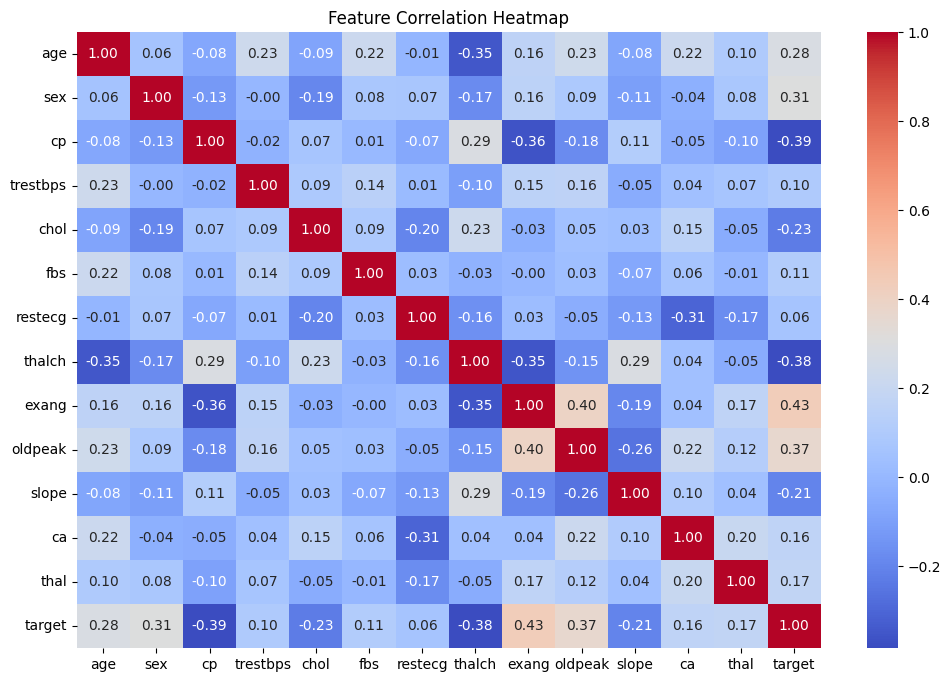

--- Model Performance Metrics ---
Accuracy:  0.7826
Precision: 0.8632
Recall:    0.7523
F1 Score:  0.8039

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.70      0.83      0.76        75
           1       0.86      0.75      0.80       109

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.80      0.78      0.78       184



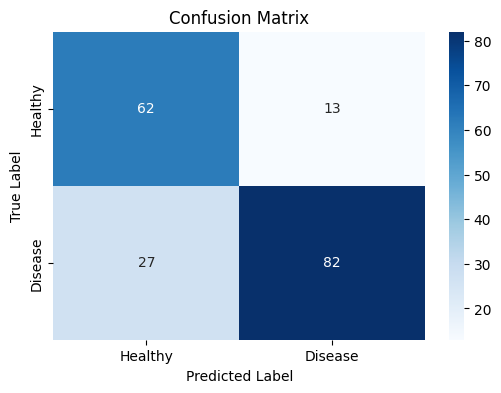

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ==========================================
# 1. DATA PREPARATION & EDA
# ==========================================

# Load the dataset
df = pd.read_csv('heart_disease_uci.csv')

# Define the target: 'num' > 0 means heart disease is present (1), 0 means healthy (0)
df['target'] = (df['num'] > 0).astype(int)

# Drop unnecessary columns: 'id' is just an index, 'dataset' is the origin, 'num' is the old target
df = df.drop(columns=['id', 'dataset', 'num'])

# Handle Missing Values
# We fill numeric columns with the median and categorical columns with the mode (most frequent value)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode Categorical Variables (Convert text to numbers)
le = LabelEncoder()
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# ==========================================
# 2. DATA VISUALIZATION
# ==========================================

# Correlation Heatmap to see relationships between features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# ==========================================
# 3. MODEL TRAINING
# ==========================================

# Define Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling: Essential for Logistic Regression to perform well
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# ==========================================
# 4. MODEL EVALUATION
# ==========================================

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate Evaluation Metrics
print("--- Model Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

# Detailed Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()